<h2 style="color:blue" align="center">Tensorboard demo using handwritten digits classification using neural network</h2>

In this notebook we will classify handwritten digits using a simple neural network which has only input and output layers. We will than add a hidden layer and see how the performance of the model improves

In [3]:
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
%matplotlib inline
import numpy as np

In [4]:
(X_train, y_train) , (X_test, y_test) = keras.datasets.mnist.load_data()

In [5]:
len(X_train)

60000

In [6]:
len(X_test)

10000

In [7]:
X_train[0].shape

(28, 28)

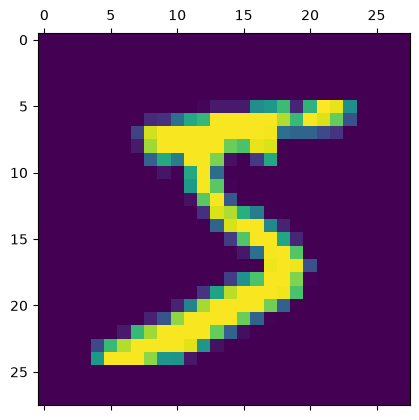

In [8]:
plt.matshow(X_train[0])

In [9]:
y_train[0]

np.uint8(5)

In [10]:
X_train = X_train / 255
X_test = X_test / 255

In [11]:
X_train_flattened = X_train.reshape(len(X_train), 28*28)
X_test_flattened = X_test.reshape(len(X_test), 28*28)

In [12]:
X_train_flattened.shape

(60000, 784)

<h3 style='color:purple'>Using Flatten layer so that we don't have to call .reshape on input dataset</h3>

In [14]:
!pip install TensorBoard 

  Using cached werkzeug-3.1.8-py3-none-any.whl.metadata (4.0 kB)
   ---------------------------------------- 0.0/5.5 MB ? eta -:--:--
   --------- ------------------------------ 1.3/5.5 MB 11.2 MB/s eta 0:00:01
   ---------------------------------------- 5.5/5.5 MB 17.7 MB/s  0:00:00
Using cached werkzeug-3.1.8-py3-none-any.whl (226 kB)

   ---------------------------------------- 0/4 [werkzeug]
   ---------------------------------------- 0/4 [werkzeug]
   -------------------- ------------------- 2/4 [markdown]
   -------------------- ------------------- 2/4 [markdown]
   ------------------------------ --------- 3/4 [TensorBoard]
   ------------------------------ --------- 3/4 [TensorBoard]
   ------------------------------ --------- 3/4 [TensorBoard]
   ------------------------------ --------- 3/4 [TensorBoard]
   ------------------------------ --------- 3/4 [TensorBoard]
   ------------------------------ --------- 3/4 [TensorBoard]
   ------------------------------ --------- 3/4 [Ten

In [15]:
model = keras.Sequential([
    keras.layers.Flatten(input_shape=(28, 28)),
    keras.layers.Dense(100, activation='relu'),
    keras.layers.Dense(10, activation='sigmoid')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

tb_callback = tf.keras.callbacks.TensorBoard(log_dir="logs/", histogram_freq=1)

model.fit(X_train, y_train, epochs=5, callbacks=[tb_callback])

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.9225 - loss: 0.2744
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9633 - loss: 0.1245
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9733 - loss: 0.0873
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9800 - loss: 0.0654
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9836 - loss: 0.0531


In [16]:
# %load_ext tensorboard
# %tensorboard --logdir logs/fit

Either run above inline magic or go to git bash or your command prompt and type below to run it,
`tensorboard --logdir logs/`
This will launch tensorboard at this url which you can open in your browser `http://localhost:6006/`

In [17]:
model.get_weights()

[array([[-0.06592664, -0.00128165, -0.02383883, ...,  0.00636292,
          0.04260333, -0.0158205 ],
        [-0.04706399,  0.05707476,  0.01705077, ...,  0.03290571,
         -0.07176467,  0.05152035],
        [ 0.0346276 ,  0.07712238,  0.05619434, ...,  0.07936858,
         -0.0599545 , -0.02019072],
        ...,
        [-0.02428274,  0.08055638, -0.03773256, ...,  0.01185191,
          0.07425748, -0.07106578],
        [-0.0198058 , -0.03260694, -0.01608358, ..., -0.02916464,
         -0.06483943, -0.02618377],
        [-0.00371657,  0.03984731, -0.07230563, ..., -0.06554411,
         -0.03717519, -0.00149962]], shape=(784, 100), dtype=float32),
 array([-0.02982985,  0.09050313, -0.07863712, -0.03030968, -0.01059587,
         0.12144425, -0.00413701,  0.06684853, -0.1019633 , -0.06362191,
         0.0469692 ,  0.20594746,  0.00932137, -0.05526964,  0.28322178,
         0.0577289 ,  0.04277546,  0.00445014, -0.02262008,  0.0415395 ,
         0.08973081, -0.02131848, -0.03075627,  